In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller

In [117]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [118]:
data = pd.read_csv('Data/preprocessed/stacked_lmp_price_data.csv')
data.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
data = data[['begin_time', 'NP-15 LMP']]
data['begin_time']=pd.to_datetime(data['begin_time'])
data

,begin_time,NP-15 LMP
0,2021-01-01 00:00:00,30.76070
1,2021-01-01 00:05:00,33.28136
2,2021-01-01 00:10:00,33.98668
3,2021-01-01 00:15:00,31.35044
4,2021-01-01 00:20:00,32.65816
...,...,...
390746,2024-12-31 23:35:00,45.51538
390747,2024-12-31 23:40:00,45.51538
390748,2024-12-31 23:45:00,46.04096
390749,2024-12-31 23:50:00,46.04096


In [119]:
data.groupby(data['begin_time']).count().value_counts()

NP-15 LMP
1            390654
2                48
0                 1
Name: count, dtype: int64

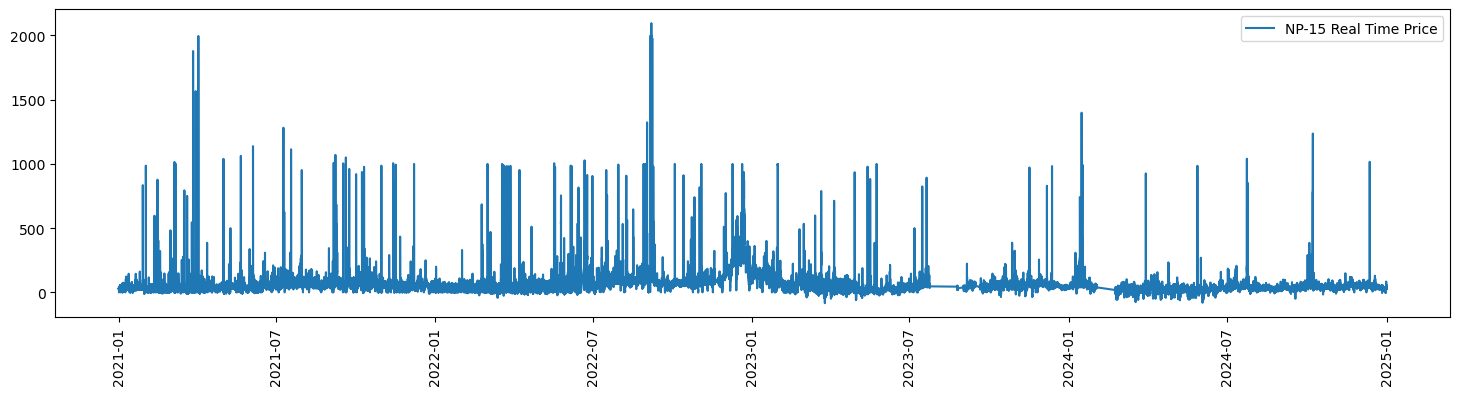

In [120]:
plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['NP-15 LMP'] , label='NP-15 Real Time Price')
plt.xticks(rotation=90)
plt.legend()
plt.show()

The figure indicates prices for some time points are missing in the second half of 2023. We compare the total number of time points we expect against the number available.

In [121]:
print(f'{len(pd.date_range(start=data['begin_time'].min(), end=data['begin_time'].max(), freq='5min'))}')
print(f"{len(data)}")

420768
390751


Clearly there are missing times. We fill in the values of missing times and take the average price where there are two prices for the same time.

In [122]:
def process_begin_times(df):
    df['begin_time'] = pd.to_datetime(df['begin_time'])
    df.set_index('begin_time', inplace=True)
    df = df.groupby(df.index).mean()
    dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='5min')
    df = df.reindex(dates)
    df.reset_index(inplace=True)
    df.rename(columns={'index':'begin_time'}, inplace=True)
    return df 

In [123]:
data= process_begin_times(data)
data

,begin_time,NP-15 LMP
0,2021-01-01 00:00:00,30.76070
1,2021-01-01 00:05:00,33.28136
2,2021-01-01 00:10:00,33.98668
3,2021-01-01 00:15:00,31.35044
4,2021-01-01 00:20:00,32.65816
...,...,...
420763,2024-12-31 23:35:00,45.51538
420764,2024-12-31 23:40:00,45.51538
420765,2024-12-31 23:45:00,46.04096
420766,2024-12-31 23:50:00,46.04096


Next we check for missing values.

In [124]:
DailyNANCounts = data.groupby(data['begin_time'].apply(lambda x: x.date())).apply(lambda g: g.isna().sum())
DailyNANCounts.drop(columns=['begin_time'], inplace=True)
DailyNANCounts.reset_index(inplace=True)
DailyNANCounts
DailyNANCounts['NP-15 LMP'].value_counts().sum()

np.int64(1461)

The number of missing values is negligible compared to total number of observations, so we don't attempt to deal with missing data. Let us filter the data at 15 min frequency.

In [125]:
data_15min = data[data['begin_time'].apply(lambda x : x.minute%15==0)].copy()
data_15min

,begin_time,NP-15 LMP
0,2021-01-01 00:00:00,30.76070
3,2021-01-01 00:15:00,31.35044
6,2021-01-01 00:30:00,32.45147
9,2021-01-01 00:45:00,29.98897
12,2021-01-01 01:00:00,29.89887
...,...,...
420753,2024-12-31 22:45:00,45.92347
420756,2024-12-31 23:00:00,46.50217
420759,2024-12-31 23:15:00,46.25834
420762,2024-12-31 23:30:00,45.51538


We check the average price at each time point.

In [126]:
avgs = data_15min['NP-15 LMP'].groupby(data['begin_time'].apply(lambda x: (x.hour, x.minute))).mean()
for i in range(len(avgs)):
    print(f"{avgs.index[i]} -> {avgs.iloc[i]}")

(0, 0) -> 58.54093223451327
(0, 15) -> 59.056059085545726
(0, 30) -> 58.16793310243183
(0, 45) -> 54.69315473451328
(1, 0) -> 55.988188178807945
(1, 15) -> 54.843561117647056
(1, 30) -> 53.44605573062731
(1, 45) -> 52.745923207964594
(2, 0) -> 53.96260652623799
(2, 15) -> 53.278953949704146
(2, 30) -> 52.340773325942344
(2, 45) -> 51.70624028739867
(3, 0) -> 52.22317924944812
(3, 15) -> 52.08509176470588
(3, 30) -> 52.31390108088235
(3, 45) -> 52.93759841293167
(4, 0) -> 51.203034642593956
(4, 15) -> 52.44612304411765
(4, 30) -> 54.44673443056576
(4, 45) -> 56.33386847569955
(5, 0) -> 53.23395236590742
(5, 15) -> 55.11368328434974
(5, 30) -> 58.72029744852941
(5, 45) -> 62.68783257898604
(6, 0) -> 60.255213578251286
(6, 15) -> 62.27301815305371
(6, 30) -> 64.9254334313005
(6, 45) -> 64.25973543382352
(7, 0) -> 71.99117075846834
(7, 15) -> 65.9216644035346
(7, 30) -> 59.58179008100147
(7, 45) -> 50.27459971302428
(8, 0) -> 55.3362006107432
(8, 15) -> 54.495562803532
(8, 30) -> 47.724989

This supports our intuition that price time series is not stationary since the averages at different times are different. So we look at 24hr differences.

In [127]:
data_15min['NP-15 LMP 24hrdiffs'] = data_15min['NP-15 LMP'] - data_15min['NP-15 LMP'].shift(24*4)
data_15min['NP-15 LMP Prev_day_price'] = data_15min['NP-15 LMP'].shift(24*4)

Let us look at a plot of the 24hr price differences over a period of one month.

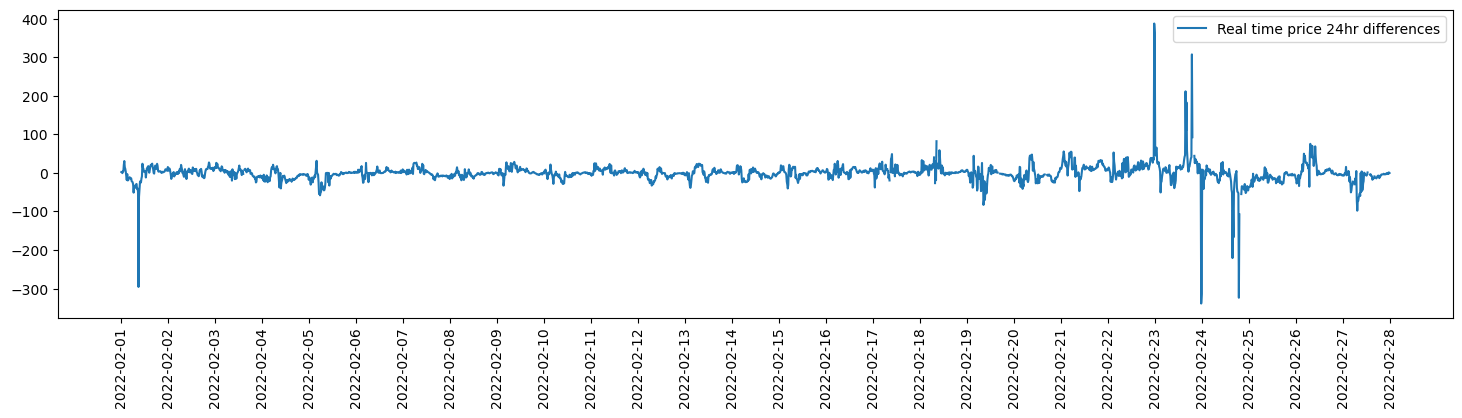

In [131]:
time1 = datetime.datetime(2022, 2, 1, 6, 0, 0)
time2 = datetime.datetime(2022, 2, 28, 6, 0, 0)

filtered_data = data_15min[filter_times(data_15min, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['NP-15 LMP 24hrdiffs'] , label='Real time price 24hr differences')

plt.xticks(ticks=pd.date_range(start=time1, end=time2, freq='1d'), labels=[x.date() for x in pd.date_range(start=time1, end=time2, freq='1d')], rotation=90)
plt.legend()
plt.show()

We don't see any apparent trend or seasonality so we can check for stationarity using the ADF test.

In [70]:
result = adfuller(data_15min['NP-15 LMP 24hrdiffs'].dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -34.64407380661819
p-value: 0.0
Critical Values:
   1%: -3.4304016086280584
   5%: -2.861562810258041
   10%: -2.566782141092938


The small p value rejects the null hypothesis that there exists a unit roor (or that the series is non stationary). Let us look at ACF and PACF plots.

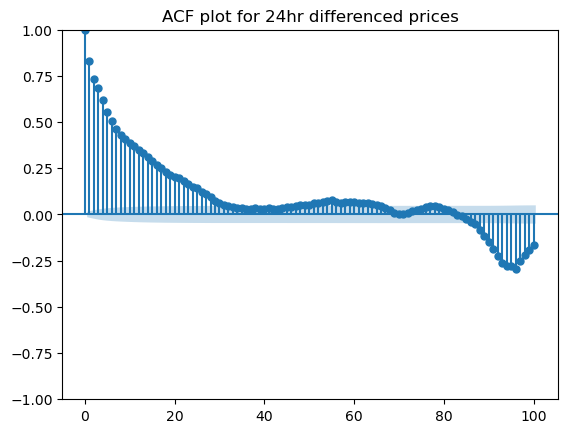

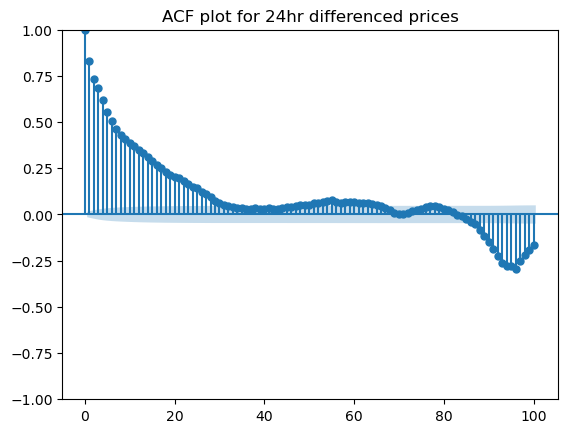

In [95]:
statsmodels.graphics.tsaplots.plot_acf(data_15min['NP-15 LMP 24hrdiffs'].iloc[40000:60000].dropna(), lags=100, title="ACF plot for 24hr differenced prices")

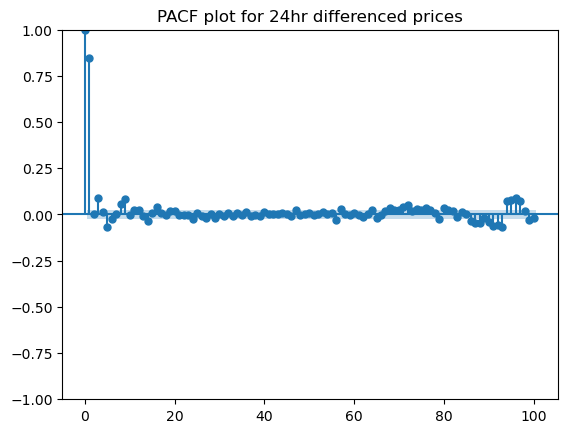

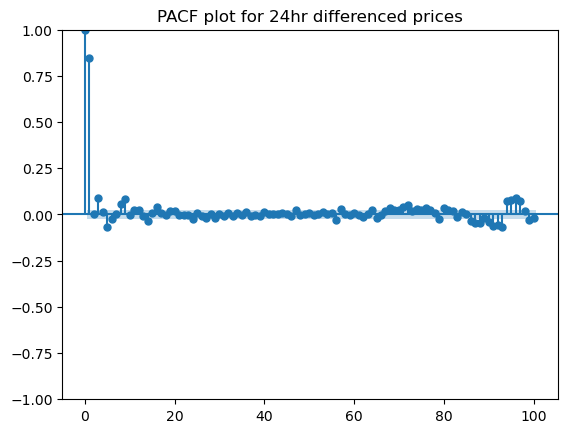

In [97]:
statsmodels.graphics.tsaplots.plot_pacf(data_15min['NP-15 LMP 24hrdiffs'].iloc[50000:59000].dropna(), lags=100, title="PACF plot for 24hr differenced prices")

In preparation for a SARIMA model Peaks around 96 suggest a seasonal AR component of order 96, and non seasonal AR components of small order.

In [71]:
from statsmodels.tsa.stattools import pacf

pacf_values = pacf(data_15min['NP-15 LMP 24hrdiffs'].iloc[50000:59000].dropna(), nlags=200)

for index, item in enumerate(pacf_values):
    print(f"{index} -> {item}")

0 -> 1.0
1 -> 0.8495117369810522
2 -> 9.74624880308435e-05
3 -> 0.08912501095442851
4 -> 0.011706068742390184
5 -> -0.06953022115860158
6 -> -0.02410228485828329
7 -> 0.002844222276068986
8 -> 0.05825047134054982
9 -> 0.08171146965167764
10 -> -0.0029530166537757676
11 -> 0.023425337925778597
12 -> 0.025043643891478073
13 -> -0.008606459670997138
14 -> -0.03352235972023081
15 -> 0.0063251598221056434
16 -> 0.041238740055572654
17 -> 0.00533093760474977
18 -> -0.003359291152870416
19 -> 0.01758009728055699
20 -> 0.020287573203692497
21 -> -0.0021504379104261965
22 -> -0.002993064764275425
23 -> -0.0023118424931311823
24 -> -0.022084635918893633
25 -> 0.007791672641232522
26 -> -0.007606785765094387
27 -> -0.016874077686069387
28 -> 0.0032531460989669954
29 -> -0.017944636024160354
30 -> 0.005076438723344367
31 -> -0.010586148644049935
32 -> 0.00533908780550253
33 -> -0.005565809721059946
34 -> 0.009510484376757727
35 -> -0.005347737633354251
36 -> 0.012198129947912924
37 -> -0.005947281

In [52]:
data.to_csv('Data/preprocessed/NP15_rt_series.csv', index=False)